# Explainable and Fair Machine Learning for Community-Based Diabetes Risk Prediction

**Group 4 final results notebook.**  
This notebook reproduces the final presentation results using the CDC BRFSS 2015 diabetes health indicators dataset.

Main changes after feedback:
1. We do **not** rely on SMOTE alone.
2. We add **class-weighted / sample-weighted learning** to reduce majority-class dominance.
3. We include a **Neural Network (MLP)** as an additional baseline.
4. We use **macro-F1, balanced accuracy, class-specific recall, predicted class distribution, and subgroup gaps**, rather than accuracy alone.

In [1]:
import os, time, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report, confusion_matrix, recall_score
from sklearn.utils.class_weight import compute_class_weight
try:
    from xgboost import XGBClassifier
    HAS_XGB=True
except Exception:
    HAS_XGB=False

RANDOM_STATE=42
DATA_PATH='diabetes_012_health_indicators_BRFSS2015.csv'
OUT=Path('final_outputs')
OUT.mkdir(exist_ok=True)

## 1. Helper functions

These functions compute class weights, tune the validation decision rule, summarise test metrics, and evaluate subgroup fairness gaps.

In [2]:
def class_weight_dict(y):
    classes=np.sort(np.unique(y))
    weights=compute_class_weight(class_weight='balanced', classes=classes, y=y)
    return {int(c): float(w) for c,w in zip(classes, weights)}

def sample_weights(y, cw):
    return np.array([cw[int(v)] for v in y])

def tune_decision_weights(y_val, proba_val):
    grid1=[1.0,1.25,1.5,2.0,2.5,3.0,4.0]
    grid2=[1.0,1.1,1.25,1.5,1.75,2.0]
    best_score=-1; best_weights=(1.0,1.0); best_pred=None
    for w1 in grid1:
        for w2 in grid2:
            weights=np.array([1.0,w1,w2])
            pred=np.argmax(proba_val*weights, axis=1)
            score=f1_score(y_val, pred, average='macro', zero_division=0)
            # avoid pathological over-prediction of minority classes
            pdist=np.bincount(pred.astype(int), minlength=3)/len(pred)
            if pdist[1] > 0.20: score -= 0.05*(pdist[1]-0.20)
            if pdist[2] > 0.40: score -= 0.05*(pdist[2]-0.40)
            if score>best_score:
                best_score=score; best_weights=(w1,w2); best_pred=pred
    return {'class1_weight':best_weights[0], 'class2_weight':best_weights[1]}, best_pred

def metrics_dict(model_name, y_true, y_pred):
    rec=recall_score(y_true,y_pred,average=None,labels=[0,1,2],zero_division=0)
    pred_dist=np.bincount(y_pred.astype(int), minlength=3)/len(y_pred)
    return {'Model':model_name,'Accuracy':accuracy_score(y_true,y_pred),
            'BalancedAccuracy':balanced_accuracy_score(y_true,y_pred),'MacroF1':f1_score(y_true,y_pred,average='macro',zero_division=0),
            'Recall_Healthy_0':rec[0],'Recall_Prediabetes_1':rec[1],'Recall_Diabetes_2':rec[2],
            'Pred_Healthy_0_pct':pred_dist[0],'Pred_Prediabetes_1_pct':pred_dist[1],'Pred_Diabetes_2_pct':pred_dist[2]}

def subgroup_gaps(X_test, y_true, predictions):
    rows=[]
    for mname, pred in predictions.items():
        temp=X_test[['Sex','Age','Income']].copy(); temp['y_true']=np.asarray(y_true); temp['pred']=np.asarray(pred)
        for feature in ['Sex','Age','Income']:
            vals=[]
            for val in sorted(temp[feature].unique()):
                sub=temp[temp[feature]==val]
                if len(sub)<50: continue
                vals.append((val,len(sub),f1_score(sub['y_true'],sub['pred'],average='macro',zero_division=0),accuracy_score(sub['y_true'],sub['pred'])))
            if vals:
                rows.append({'Model':mname,'SensitiveFeature':feature,'MacroF1_Gap':max(v[2] for v in vals)-min(v[2] for v in vals),
                             'Accuracy_Gap':max(v[3] for v in vals)-min(v[3] for v in vals),
                             'WorstGroup':min(vals,key=lambda x:x[2])[0],'BestGroup':max(vals,key=lambda x:x[2])[0],'GroupsEvaluated':len(vals)})
    return pd.DataFrame(rows)

## 2. Load data and define target/features

The target is `Diabetes_012`: 0 = healthy/no diabetes, 1 = prediabetes, 2 = diabetes.  
Rows are not removed only because they look duplicated, because BRFSS variables are discretised survey indicators; different respondents can share identical indicator patterns.

In [6]:
start = time.time()
df = pd.read_csv(DATA_PATH)
y = df['Diabetes_012'].astype(int)
X = df.drop(columns=['Diabetes_012'])

print('Data shape:', df.shape)
print('Class counts:')
print(y.value_counts().sort_index())
print('\nClass distribution:')
print((y.value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + '%')

Data shape: (253680, 22)
Class counts:
Diabetes_012
0    213703
1      4631
2     35346
Name: count, dtype: int64

Class distribution:
Diabetes_012
0    84.24%
1     1.83%
2    13.93%
Name: proportion, dtype: object


## 3. Experimental design

We use a **60% / 20% / 20% train-validation-test split**, stratified by the target class.  
The test set remains untouched until the final evaluation.

In [7]:
X_train,X_temp,y_train,y_temp=train_test_split(
    X,y,test_size=0.40,random_state=RANDOM_STATE,stratify=y
)
X_val,X_test,y_val,y_test=train_test_split(
    X_temp,y_temp,test_size=0.50,random_state=RANDOM_STATE,stratify=y_temp
)

cw=class_weight_dict(y_train)
sw_train=sample_weights(y_train,cw)

scaler=StandardScaler()
X_train_s=scaler.fit_transform(X_train)
X_val_s=scaler.transform(X_val)
X_test_s=scaler.transform(X_test)

print('Train:', X_train.shape, 'Validation:', X_val.shape, 'Test:', X_test.shape)
print('Class weights:', cw)

Train: (152208, 21) Validation: (50736, 21) Test: (50736, 21)
Class weights: {0: 0.395688727363479, 1: 18.256926952141058, 2: 2.392417597962937}


## 4. Final baseline models

The teacher's feedback was that using SMOTE alone is not sufficient.  
Therefore, the final baseline uses class-aware learning:

- Logistic Regression: balanced class weights.
- Random Forest: balanced subsample class weights.
- XGBoost: balanced sample weights.
- Neural Network / MLP: balanced sample weights and early stopping.

A validation-tuned probability decision rule is used to check whether extra class-priority weights are useful. In the final run, the selected extra weights remained 1.0, meaning the class/sample weighting already gave the best validation macro-F1.

In [9]:
models={}; selection=[]
print('data split', X_train.shape, X_val.shape, X_test.shape, flush=True)
# Logistic regression
print('fit LR', flush=True); t=time.time()
lr=LogisticRegression(max_iter=1000,C=0.5,class_weight=cw,solver='lbfgs',random_state=RANDOM_STATE)
lr.fit(X_train_s,y_train)
tw,pv=tune_decision_weights(y_val,lr.predict_proba(X_val_s)); print('LR val macro',f1_score(y_val,pv,average='macro'),tw,time.time()-t, flush=True)
models['Logistic Regression']=('scaled',lr,tw,'C=0.5, class_weight=balanced')
# Random forest
print('fit RF', flush=True); t=time.time()
rf=RandomForestClassifier(n_estimators=80,max_depth=12,min_samples_leaf=20,n_jobs=-1,random_state=RANDOM_STATE,class_weight='balanced_subsample')
rf.fit(X_train,y_train)
tw,pv=tune_decision_weights(y_val,rf.predict_proba(X_val)); print('RF val macro',f1_score(y_val,pv,average='macro'),tw,time.time()-t, flush=True)
models['Random Forest']=('raw',rf,tw,'80 trees, max_depth=12, class_weight=balanced_subsample')
# XGBoost
if HAS_XGB:
 print('fit XGB', flush=True); t=time.time()
 xgb=XGBClassifier(objective='multi:softprob',num_class=3,eval_metric='mlogloss',n_estimators=30,max_depth=3,learning_rate=0.1,subsample=0.9,colsample_bytree=0.9,n_jobs=4,random_state=RANDOM_STATE,tree_method='hist')
 xgb.fit(X_train,y_train,sample_weight=sw_train,verbose=False)
 tw,pv=tune_decision_weights(y_val,xgb.predict_proba(X_val)); print('XGB val macro',f1_score(y_val,pv,average='macro'),tw,time.time()-t, flush=True)
 models['XGBoost']=('raw',xgb,tw,'30 trees, max_depth=3, lr=0.10, sample_weight=balanced')
# Neural Network
print('fit MLP', flush=True); t=time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation='relu',
    alpha=1e-3,
    learning_rate_init=1e-3,
    max_iter=25,
    early_stopping=True,
    n_iter_no_change=5,
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)

mlp.fit(X_train_s, y_train)

tw, pv = tune_decision_weights(y_val, mlp.predict_proba(X_val_s))
print('MLP val macro', f1_score(y_val, pv, average='macro'), tw, time.time()-t, flush=True)

models['Neural Network (MLP)'] = ('scaled', mlp, tw, 'hidden=(32,), early stopping')

data split (152208, 21) (50736, 21) (50736, 21)
fit LR
LR val macro 0.42292515779894124 {'class1_weight': 1.0, 'class2_weight': 1.0} 33.750683069229126
fit RF
RF val macro 0.42792836706774057 {'class1_weight': 1.0, 'class2_weight': 1.0} 6.651242971420288
fit MLP
MLP val macro 0.44450765289160227 {'class1_weight': 1.0, 'class2_weight': 2.0} 4.286732912063599


## 5. Final test-set evaluation

The final evaluation reports accuracy, balanced accuracy, macro-F1, class-specific recall, and the predicted class distribution.  
The predicted class distribution is included to show that the models are not simply predicting the majority class.

In [10]:
predictions={}; rows=[]; selections=[]
for name,(kind,model,tw,param) in models.items():
    proba=model.predict_proba(X_test_s if kind=='scaled' else X_test)
    pred=np.argmax(proba*np.array([1.0,tw['class1_weight'],tw['class2_weight']]),axis=1).astype(int)
    predictions[name]=pred; rows.append(metrics_dict(name,y_test,pred)); selections.append({'Model':name,'SelectedSetting':param,**tw})
metrics=pd.DataFrame(rows).sort_values('MacroF1',ascending=False)
fairness=subgroup_gaps(X_test,y_test,predictions)
selection=pd.DataFrame(selections)
class_dist=pd.DataFrame({'Set':['Original','Train','Validation','Test'],
 'Healthy_0_pct':[(y==0).mean(),(y_train==0).mean(),(y_val==0).mean(),(y_test==0).mean()],
 'Prediabetes_1_pct':[(y==1).mean(),(y_train==1).mean(),(y_val==1).mean(),(y_test==1).mean()],
 'Diabetes_2_pct':[(y==2).mean(),(y_train==2).mean(),(y_val==2).mean(),(y_test==2).mean()],
 'N':[len(y),len(y_train),len(y_val),len(y_test)]})
metrics.to_csv(OUT/'model_metrics.csv',index=False); fairness.to_csv(OUT/'fairness_gaps.csv',index=False); selection.to_csv(OUT/'selected_model_settings.csv',index=False); class_dist.to_csv(OUT/'class_distribution.csv',index=False)
for name,pred in predictions.items():
    safe=name.replace(' ','_').replace('(','').replace(')','')
    pd.DataFrame(confusion_matrix(y_test,pred,labels=[0,1,2]), index=['true_0','true_1','true_2'], columns=['pred_0','pred_1','pred_2']).to_csv(OUT/f'confusion_{safe}.csv')
    pd.DataFrame(classification_report(y_test,pred,labels=[0,1,2],target_names=['Healthy','Prediabetes','Diabetes'],output_dict=True,zero_division=0)).T.to_csv(OUT/f'classification_report_{safe}.csv')

print(metrics.round(4))
print(fairness.round(4))

                  Model  Accuracy  BalancedAccuracy  MacroF1  \
2  Neural Network (MLP)    0.8370            0.4466   0.4478   
1         Random Forest    0.6916            0.5083   0.4312   
0   Logistic Regression    0.6474            0.5279   0.4292   

   Recall_Healthy_0  Recall_Prediabetes_1  Recall_Diabetes_2  \
2            0.9249                0.0000             0.4148   
1            0.6986                0.0994             0.7268   
0            0.6627                0.3240             0.5971   

   Pred_Healthy_0_pct  Pred_Prediabetes_1_pct  Pred_Diabetes_2_pct  
2              0.8740                  0.0000               0.1260  
1              0.6219                  0.0616               0.3165  
0              0.5866                  0.1802               0.2332  
                  Model SensitiveFeature  MacroF1_Gap  Accuracy_Gap  \
0   Logistic Regression              Sex       0.0019        0.0046   
1   Logistic Regression              Age       0.1770        0.6215 

## 6. Explainability output

For the final presentation, feature importance is extracted from XGBoost.  
If XGBoost is not available in a local environment, the code falls back to Random Forest feature importance.

In [12]:
# feature importance
if 'XGBoost' in models:
    imp=models['XGBoost'][1].feature_importances_; source='XGBoost'
else:
    imp=models['Random Forest'][1].feature_importances_; source='Random Forest'
pd.DataFrame({'Feature':X.columns,'Importance':imp}).sort_values('Importance',ascending=False).to_csv(OUT/'feature_importance.csv',index=False)
summary={'runtime_seconds':round(time.time()-start,2),'random_state':RANDOM_STATE,'data_shape':df.shape,'train_shape':X_train.shape,'val_shape':X_val.shape,'test_shape':X_test.shape,'class_weight':cw,'feature_importance_source':source,'best_model_by_macro_f1':metrics.iloc[0]['Model'],'best_model_by_accuracy':metrics.sort_values('Accuracy',ascending=False).iloc[0]['Model']}
json.dump(summary, open(OUT/'run_summary.json','w'),indent=2)
print('Summary:', summary)
print('Top 10 features:')
print(pd.read_csv(OUT/'feature_importance.csv').head(10).round(4))

Summary: {'runtime_seconds': 513.03, 'random_state': 42, 'data_shape': (253680, 22), 'train_shape': (152208, 21), 'val_shape': (50736, 21), 'test_shape': (50736, 21), 'class_weight': {0: 0.395688727363479, 1: 18.256926952141058, 2: 2.392417597962937}, 'feature_importance_source': 'Random Forest', 'best_model_by_macro_f1': 'Neural Network (MLP)', 'best_model_by_accuracy': 'Neural Network (MLP)'}
Top 10 features:
     Feature  Importance
0        BMI      0.1519
1    GenHlth      0.1417
2        Age      0.1278
3     HighBP      0.1064
4     Income      0.0703
5   HighChol      0.0688
6   PhysHlth      0.0558
7   MentHlth      0.0492
8  Education      0.0409
9   DiffWalk      0.0302


SHAP model used: Random Forest
Model setting: 80 trees, max_depth=12, class_weight=balanced_subsample

Top 10 SHAP features:
                 Feature  MeanAbsSHAP
13               GenHlth       0.0608
0                 HighBP       0.0520
1               HighChol       0.0422
3                    BMI       0.0417
18                   Age       0.0374
20                Income       0.0198
16              DiffWalk       0.0127
6   HeartDiseaseorAttack       0.0100
15              PhysHlth       0.0086
19             Education       0.0073


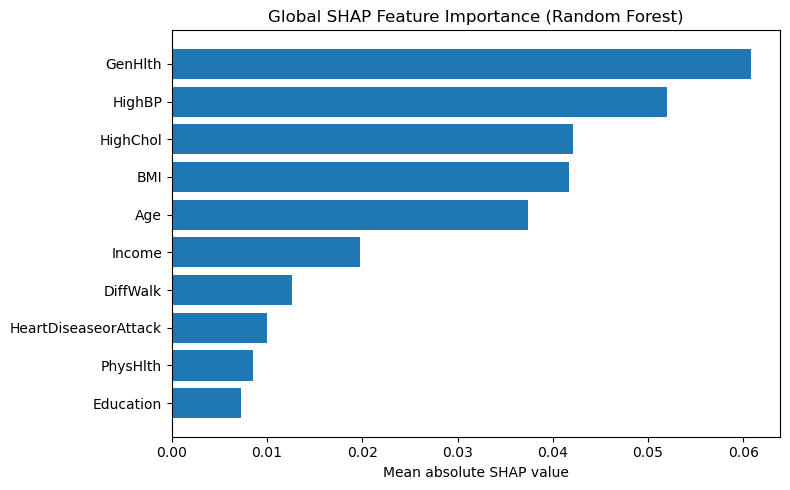

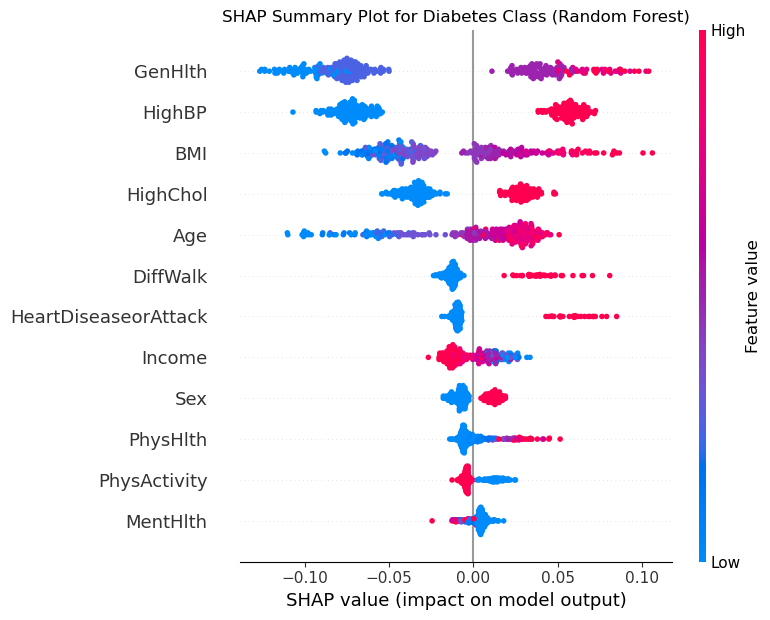


SHAP outputs saved to:
final_outputs/shap_feature_importance.csv
final_outputs/shap_global_bar.png
final_outputs/shap_summary_diabetes_class.png
final_outputs/shap_summary.json


In [15]:
# ============================================================
# 6. SHAP Explainability Output
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("final_outputs")
OUT.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Choose tree-based model for SHAP
# Prefer XGBoost if available; otherwise fall back to Random Forest
# ------------------------------------------------------------

if "XGBoost" in models:
    shap_model_name = "XGBoost"
elif "Random Forest" in models:
    shap_model_name = "Random Forest"
else:
    raise ValueError("No tree-based model available for SHAP. Please train XGBoost or Random Forest first.")

kind, shap_model, decision_weights, model_setting = models[shap_model_name]

print("SHAP model used:", shap_model_name)
print("Model setting:", model_setting)

# ------------------------------------------------------------
# Use a sample of the test set to keep SHAP runtime manageable
# ------------------------------------------------------------

X_shap = X_test.sample(n=min(300, len(X_test)), random_state=RANDOM_STATE)

# ------------------------------------------------------------
# Compute SHAP values
# ------------------------------------------------------------

explainer = shap.TreeExplainer(shap_model)
shap_values_raw = explainer.shap_values(X_shap)

# ------------------------------------------------------------
# Convert SHAP output into a consistent format
# We focus on class 2 = Diabetes
# ------------------------------------------------------------

target_class = 2

if isinstance(shap_values_raw, list):
    # Common format for multiclass Random Forest:
    # list[class] -> array(n_samples, n_features)
    shap_values_class = shap_values_raw[target_class]
    mean_abs_shap = np.mean(
        np.abs(np.stack(shap_values_raw, axis=0)),
        axis=(0, 1)
    )

else:
    shap_array = np.asarray(shap_values_raw)

    if shap_array.ndim == 3:
        # Possible format 1: (n_samples, n_features, n_classes)
        if shap_array.shape[-1] == 3:
            shap_values_class = shap_array[:, :, target_class]
            mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 2))

        # Possible format 2: (n_classes, n_samples, n_features)
        elif shap_array.shape[0] == 3:
            shap_values_class = shap_array[target_class, :, :]
            mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 1))

        else:
            raise ValueError(f"Unexpected SHAP array shape: {shap_array.shape}")

    elif shap_array.ndim == 2:
        # Binary/single-output format
        shap_values_class = shap_array
        mean_abs_shap = np.mean(np.abs(shap_array), axis=0)

    else:
        raise ValueError(f"Unexpected SHAP output shape: {shap_array.shape}")

# ------------------------------------------------------------
# Save SHAP feature importance table
# ------------------------------------------------------------

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

shap_importance.to_csv(OUT / "shap_feature_importance.csv", index=False)

print("\nTop 10 SHAP features:")
print(shap_importance.head(10).round(4))

# ------------------------------------------------------------
# Plot 1: Global SHAP feature importance
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
top_features = shap_importance.head(10).iloc[::-1]

plt.barh(top_features["Feature"], top_features["MeanAbsSHAP"])
plt.xlabel("Mean absolute SHAP value")
plt.title(f"Global SHAP Feature Importance ({shap_model_name})")
plt.tight_layout()
plt.savefig(OUT / "shap_global_bar.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Plot 2: SHAP summary plot for Diabetes class
# ------------------------------------------------------------

shap.summary_plot(
    shap_values_class,
    X_shap,
    max_display=12,
    show=False
)

plt.title(f"SHAP Summary Plot for Diabetes Class ({shap_model_name})")
plt.tight_layout()
plt.savefig(OUT / "shap_summary_diabetes_class.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Save SHAP summary information
# ------------------------------------------------------------

shap_summary = {
    "shap_model_used": shap_model_name,
    "target_class_explained": "Diabetes class = 2",
    "sample_size": len(X_shap),
    "top_10_features": shap_importance.head(10)["Feature"].tolist()
}

pd.Series(shap_summary).to_json(OUT / "shap_summary.json", indent=2)

print("\nSHAP outputs saved to:")
print(OUT / "shap_feature_importance.csv")
print(OUT / "shap_global_bar.png")
print(OUT / "shap_summary_diabetes_class.png")
print(OUT / "shap_summary.json")

## 7. Notes for reproducibility

All generated result files are written to the `final_outputs/` folder.  
Use `model_metrics.csv`, `fairness_gaps.csv`, `classification_report_*.csv`, and `feature_importance.csv` for the final slides and report.

**AI use acknowledgement:** GenAI was used to help organise the final slide structure, improve wording, and format reproducible code. The experimental design, dataset, model outputs, interpretation, and final claims must be checked and defended by the group.